# Network Traffic Anomaly Analysis (UNSW-NB15)

This notebook loads the aggregated results from the `results/` folder (written by `src/analysis.py`) and displays them through a set of standard visualizations.

In [ ]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import os

_JAVA17_HOME = "/usr/lib/jvm/java-17-openjdk-amd64"
if os.path.isdir(_JAVA17_HOME):
    os.environ["JAVA_HOME"] = _JAVA17_HOME
    os.environ["PATH"] = f"{_JAVA17_HOME}/bin:" + os.environ.get("PATH", "")


sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().resolve()
RESULTS_DIR = BASE_DIR / "results"

spark = SparkSession.builder \
    .appName("Visualization") \
    .master("local[*]") \
    .getOrCreate()

## 1. Top 10 IP Addresses by Number of Suspicious Connections

Source: `top_suspicious_ips.parquet` (Query 1)

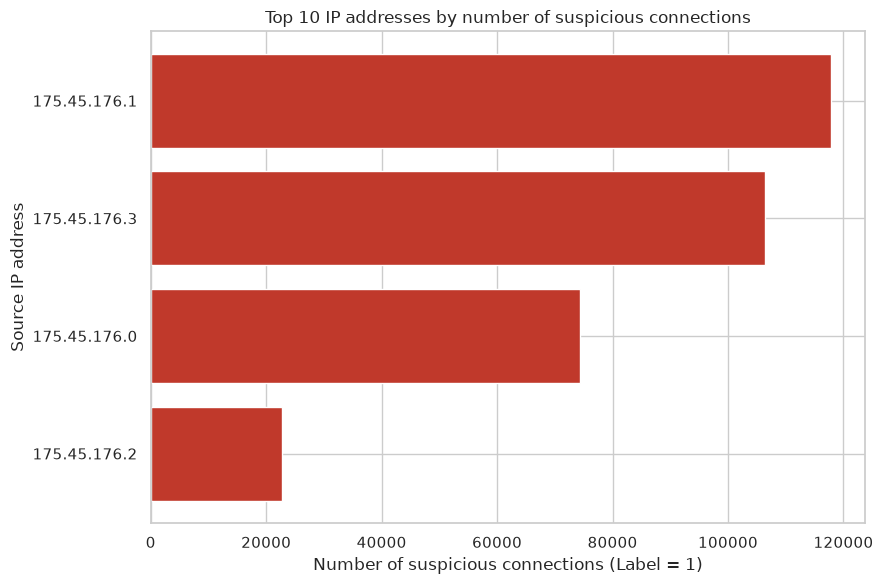

In [19]:
top_ips = spark.read.parquet(str(RESULTS_DIR / "top_suspicious_ips.parquet")).toPandas()
top_ips = top_ips.sort_values("suspicious_connections", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_ips["srcip"], top_ips["suspicious_connections"], color="#c0392b")
ax.set_xlabel("Number of suspicious connections (Label = 1)")
ax.set_ylabel("Source IP address")
ax.set_title("Top 10 IP addresses by number of suspicious connections")
plt.tight_layout()
plt.show()

## 2. Most Common Protocol by Attack Category

Source: `top_protocol_per_attack_cat.parquet` (Query 2)

In [20]:
top_proto = spark.read.parquet(str(RESULTS_DIR / "top_protocol_per_attack_cat.parquet")).toPandas()
top_proto = top_proto.sort_values("cnt", ascending=False).reset_index(drop=True)
top_proto

,attack_cat,proto,cnt
0,Generic,udp,210600
1,Exploits,tcp,27443
2,Fuzzers,tcp,15474
3,Reconnaissance,tcp,6965
4,DoS,unas,5246
5,Analysis,unas,926
6,Shellcode,udp,761
7,Backdoor,unas,600
8,Backdoors,unas,206
9,Worms,tcp,153


## 3. Attack Count Over Time (Rolling Count)

Source: `attacks_over_time.parquet` (Query 3). The `time_window` column is a struct with `start`/`end` fields, so we extract it before plotting.

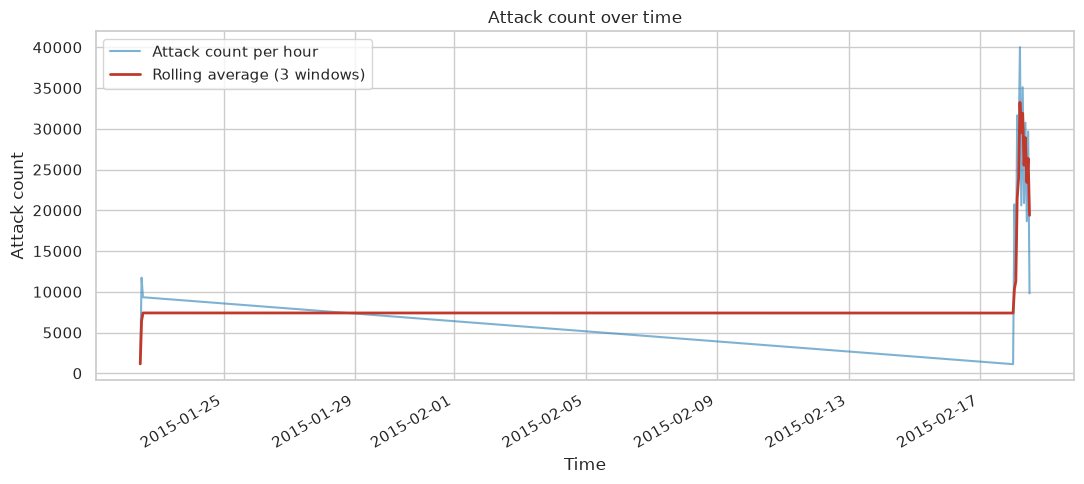

In [21]:
attacks_over_time = spark.read.parquet(str(RESULTS_DIR / "attacks_over_time.parquet"))
attacks_over_time = (
    attacks_over_time
    .selectExpr("time_window.start AS window_start", "attack_count", "rolling_avg_attacks")
    .orderBy("window_start")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(attacks_over_time["window_start"], attacks_over_time["attack_count"],
        label="Attack count per hour", color="#2980b9", alpha=0.6)
ax.plot(attacks_over_time["window_start"], attacks_over_time["rolling_avg_attacks"],
        label="Rolling average (3 windows)", color="#c0392b", linewidth=2)
ax.set_xlabel("Time")
ax.set_ylabel("Attack count")
ax.set_title("Attack count over time")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Port + Protocol Combinations Most Associated with Reconnaissance Attacks

Source: `reconnaissance_port_proto.parquet` (Query 4)

In [22]:
recon = spark.read.parquet(str(RESULTS_DIR / "reconnaissance_port_proto.parquet")).toPandas()
recon = recon.sort_values("cnt", ascending=False).reset_index(drop=True)
recon.head(15)

,dsport,proto,cnt
0,111.0,udp,4774
1,111.0,tcp,4750
2,80.0,tcp,2181
3,0.0,unas,840
4,0.0,ospf,229
5,0.0,sctp,113
6,161.0,udp,81
7,53.0,udp,21
8,0.0,any,21
9,53.0,tcp,20


## 5. Ratio of Normal to Attack Traffic by Hour of Day

Source: `normal_vs_attack_by_hour.parquet` (Query 5)

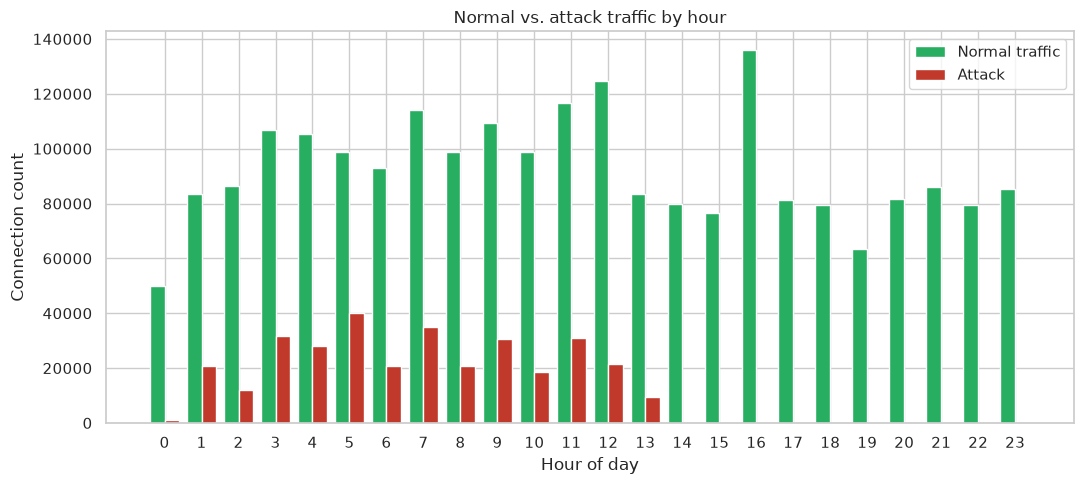

In [23]:
by_hour = spark.read.parquet(str(RESULTS_DIR / "normal_vs_attack_by_hour.parquet")).toPandas()
by_hour = by_hour.sort_values("hour_of_day")

fig, ax = plt.subplots(figsize=(11, 5))
width = 0.4
ax.bar(by_hour["hour_of_day"] - width / 2, by_hour["normal_count"], width, label="Normal traffic", color="#27ae60")
ax.bar(by_hour["hour_of_day"] + width / 2, by_hour["attack_count"], width, label="Attack", color="#c0392b")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Connection count")
ax.set_title("Normal vs. attack traffic by hour")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Attack Category Distribution

Source: `attack_cat_distribution.parquet` (Query 6)

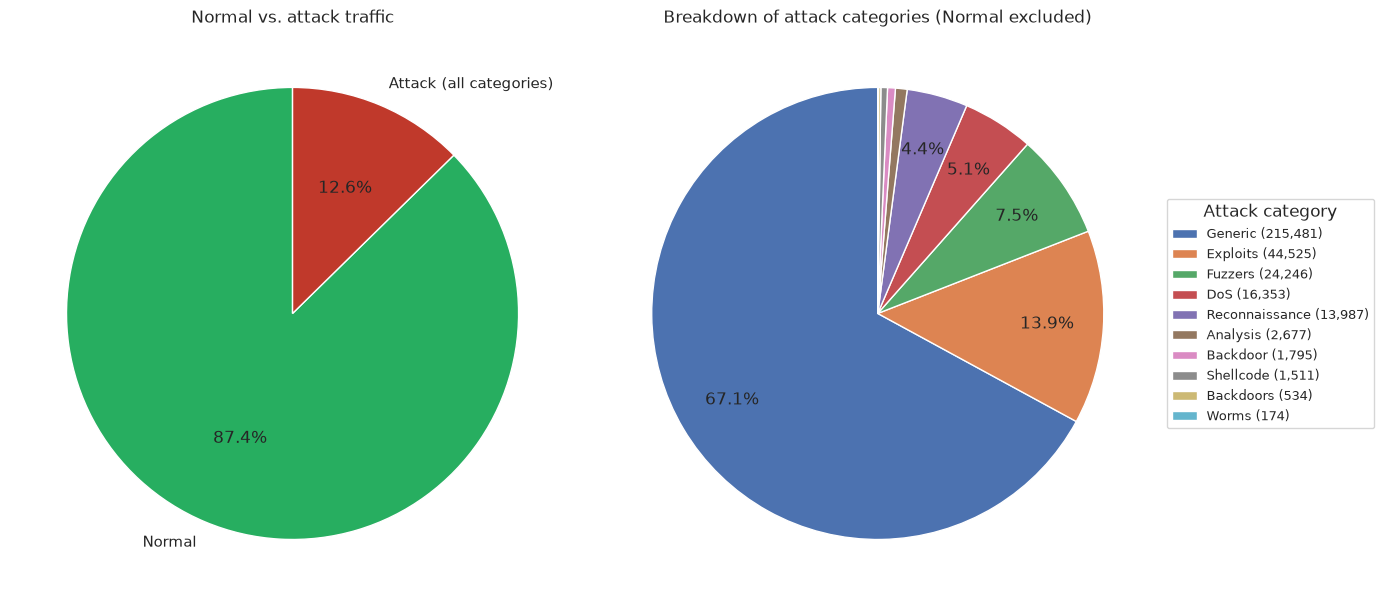

In [24]:
attack_cat_dist = spark.read.parquet(str(RESULTS_DIR / "attack_cat_distribution.parquet")).toPandas()
attack_cat_dist = attack_cat_dist.sort_values("cnt", ascending=False)

normal_count = attack_cat_dist.loc[attack_cat_dist["attack_cat"] == "Normal", "cnt"].sum()
attack_only = attack_cat_dist[attack_cat_dist["attack_cat"] != "Normal"].copy()
attack_total = attack_only["cnt"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: high-level split between normal traffic and attacks
axes[0].pie(
    [normal_count, attack_total],
    labels=["Normal", "Attack (all categories)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#27ae60", "#c0392b"],
)
axes[0].set_title("Normal vs. attack traffic")

# Right: breakdown of attack categories only (Normal excluded), so the
# smaller slices become legible instead of being squeezed by Normal's share
wedges, _, autotexts = axes[1].pie(
    attack_only["cnt"],
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    startangle=90,
    pctdistance=0.75,
)
axes[1].set_title("Breakdown of attack categories (Normal excluded)")
axes[1].legend(
    wedges,
    [f"{cat} ({cnt:,})" for cat, cnt in zip(attack_only["attack_cat"], attack_only["cnt"])],
    title="Attack category",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9,
)

plt.tight_layout()
plt.show()

## 7. Heatmap of Attack Intensity by Hour and Day of Week

Source: `attack_intensity_by_hour_day.parquet` (Query 7). `day_of_week` is Spark's `DAYOFWEEK` (1 = Sunday ... 7 = Saturday).

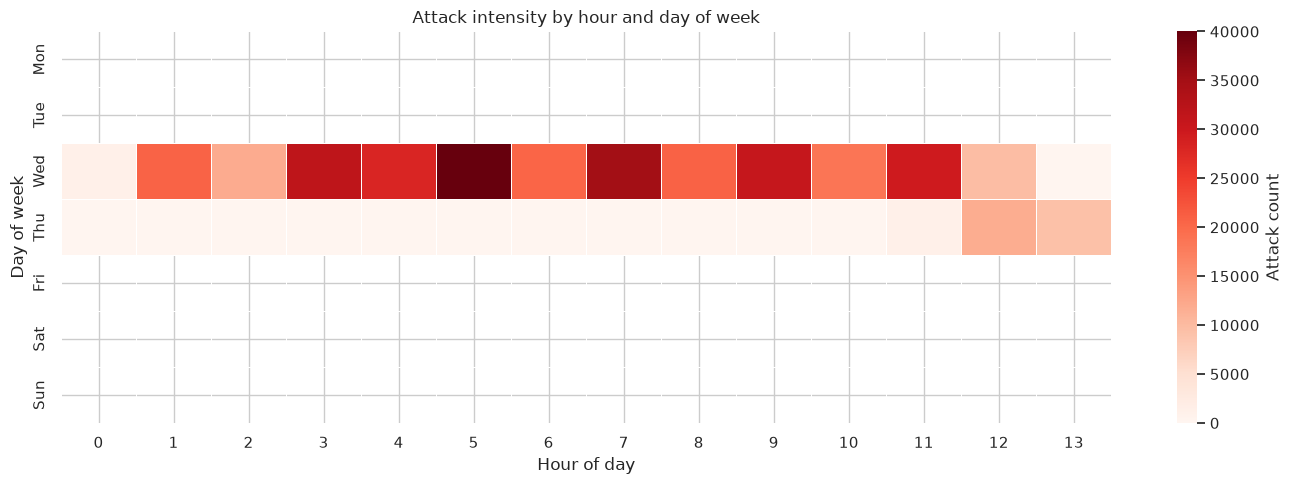

In [25]:
intensity = spark.read.parquet(str(RESULTS_DIR / "attack_intensity_by_hour_day.parquet")).toPandas()

day_labels = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
intensity["day_label"] = intensity["day_of_week"].map(day_labels)

pivot = intensity.pivot(index="day_label", columns="hour_of_day", values="cnt").fillna(0)
pivot = pivot.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="Reds", linewidths=0.5, ax=ax, cbar_kws={"label": "Attack count"})
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_title("Attack intensity by hour and day of week")
plt.tight_layout()
plt.show()

In [26]:
spark.stop()